# Import

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
#from cartopy import crs as ccrs
#from cartopy import feature as cfeature
from datetime import datetime,timedelta
#from dateutil.relativedelta import relativedelta

import geopandas as gpd
from lonboard import viz, Map, ScatterplotLayer, HeatmapLayer
import duckdb

By default, set the date and time to one hour prior to the current time. Or, specify a past date and hour.

Call time by querying

In [12]:
# Use the current time, or set your own for a past time.
# Set current to False if you want to specify a past time.

nowTime = datetime.now()

current = True
current = False
if (current):
    validTime = datetime.now()
    year = validTime.year
    month = validTime.month
    day = validTime.day
    hour = validTime.hour
    validTime = datetime(year, month, day, hour)
    offset = timedelta(hours = 1)
    validTime = validTime - offset
else:
    year = 2026
    month = 1
    day = 1
    hour = 0
    time_1 = datetime(year, month, day, hour)

In [13]:
time_0 = time_1 - timedelta(hours=1)
YYYY_0 = time_0.strftime("%Y")
YYYY_1 = time_1.strftime("%Y")
print(time_0, time_1)
# Handle edge case when the two hours straddle the end/beginning of a yearw
if (YYYY_0 == YYYY_1):
    URLs = [f'https://data.source.coop/dynamical/asos-parquet/year={YYYY_1}/data.parquet']
else:
    URLs = [f'https://data.source.coop/dynamical/asos-parquet/year={YYYY_0}/data.parquet',
            f'https://data.source.coop/dynamical/asos-parquet/year={YYYY_1}/data.parquet']


2025-12-31 23:00:00 2026-01-01 00:00:00


In [14]:
URLs

['https://data.source.coop/dynamical/asos-parquet/year=2025/data.parquet',
 'https://data.source.coop/dynamical/asos-parquet/year=2026/data.parquet']

In [15]:
df = duckdb.execute("""
    SELECT *
    FROM read_parquet($1, hive_partitioning=true)
    WHERE 
---      country = 'FR' AND
    valid BETWEEN $2 AND $3
    ORDER BY country
""", [URLs, time_0, time_1]).fetchdf()

In [16]:
df

,station,valid,longitude,latitude,tmpf,tmpc,dwpf,dwpc,relh,drct,...,state,name,elevation,country,county,wfo,tzname,geometry,bbox,year
0,YPWR,2025-12-31 23:00:00+00:00,136.8054,-31.1558,73.4,23.0,42.8,6.0,33.31,140.0,...,AU,Woomera,167.0,AU,None,None,Australia/Adelaide,"[1, 1, 0, 0, 0, 89, 134, 56, 214, 197, 25, 97,...","{'xmin': 136.8054, 'ymin': -31.1558, 'xmax': 1...",2025
1,YBRM,2026-01-01 00:00:00+00:00,122.2353,-17.9475,89.6,32.0,78.8,26.0,70.72,250.0,...,AU,Broome,9.0,AU,None,None,Australia/Perth,"[1, 1, 0, 0, 0, 236, 47, 187, 39, 15, 143, 94,...","{'xmin': 122.2353, 'ymin': -17.9475, 'xmax': 1...",2026
2,YFRT,2025-12-31 23:00:00+00:00,128.1150,-30.8381,64.4,18.0,50.0,10.0,59.52,120.0,...,AU,Forrest,156.0,AU,None,None,Australia/Perth,"[1, 1, 0, 0, 0, 72, 225, 122, 20, 174, 3, 96, ...","{'xmin': 128.115, 'ymin': -30.8381, 'xmax': 12...",2025
3,YCIN,2025-12-31 23:30:00+00:00,123.8283,-17.5814,84.2,29.0,78.8,26.0,83.93,220.0,...,AU,Derby,91.0,AU,None,None,Australia/Perth,"[1, 1, 0, 0, 0, 183, 209, 0, 222, 2, 245, 94, ...","{'xmin': 123.8283, 'ymin': -17.5814, 'xmax': 1...",2025
4,YPLM,2025-12-31 23:00:00+00:00,114.0967,-22.2406,82.4,28.0,71.6,22.0,69.97,260.0,...,AU,Learmonth,6.0,AU,None,None,Australia/Perth,"[1, 1, 0, 0, 0, 124, 97, 50, 85, 48, 134, 92, ...","{'xmin': 114.0967, 'ymin': -22.2406, 'xmax': 1...",2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7782,FAGG,2026-01-01 00:00:00+00:00,22.3789,-34.0055,68.0,20.0,68.0,20.0,100.00,NaN,...,ZA,George,193.0,ZA,None,None,Africa/Johannesburg,"[1, 1, 0, 0, 0, 84, 116, 36, 151, 255, 96, 54,...","{'xmin': 22.3789, 'ymin': -34.0055, 'xmax': 22...",2026
7783,FACT,2026-01-01 00:00:00+00:00,18.6000,-33.9667,68.0,20.0,66.2,19.0,93.98,190.0,...,ZA,Cape Town,42.0,ZA,None,None,Africa/Johannesburg,"[1, 1, 0, 0, 0, 154, 153, 153, 153, 153, 153, ...","{'xmin': 18.6, 'ymin': -33.9667, 'xmax': 18.6,...",2026
7784,FABL,2026-01-01 00:00:00+00:00,26.3024,-29.0927,59.0,15.0,57.2,14.0,93.74,NaN,...,ZA,Bloemfontein,1348.0,ZA,None,None,Africa/Johannesburg,"[1, 1, 0, 0, 0, 118, 79, 30, 22, 106, 77, 58, ...","{'xmin': 26.3024, 'ymin': -29.0927, 'xmax': 26...",2026
7785,FAWB,2026-01-01 00:00:00+00:00,28.2242,-25.6539,66.2,19.0,59.0,15.0,77.62,110.0,...,ZA,Pretoria,1248.0,ZA,None,None,Africa/Johannesburg,"[1, 1, 0, 0, 0, 97, 195, 211, 43, 101, 57, 60,...","{'xmin': 28.2242, 'ymin': -25.6539, 'xmax': 28...",2026


In [17]:
df.tmpc

0       23.0
1       32.0
2       18.0
3       29.0
4       28.0
        ... 
7782    20.0
7783    20.0
7784    15.0
7785    19.0
7786    20.0
Name: tmpc, Length: 7787, dtype: float64

In [18]:
df.country

0       AU
1       AU
2       AU
3       AU
4       AU
        ..
7782    ZA
7783    ZA
7784    ZA
7785    ZA
7786    ZA
Name: country, Length: 7787, dtype: object

In [19]:
df.valid

0      2025-12-31 23:00:00+00:00
1      2026-01-01 00:00:00+00:00
2      2025-12-31 23:00:00+00:00
3      2025-12-31 23:30:00+00:00
4      2025-12-31 23:00:00+00:00
                  ...           
7782   2026-01-01 00:00:00+00:00
7783   2026-01-01 00:00:00+00:00
7784   2026-01-01 00:00:00+00:00
7785   2026-01-01 00:00:00+00:00
7786   2025-12-31 23:47:00+00:00
Name: valid, Length: 7787, dtype: datetime64[us, UTC]

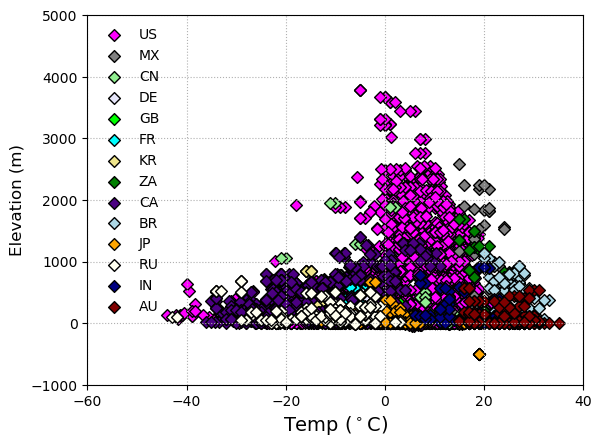

In [21]:

# Temperature in celsius
secs = list(set(df['country']))
secs

clr_dict = {
    'ZA': 'green',
    'MX': 'grey',
    'CA': 'indigo',
    'RU': 'ivory',
    'KR': 'khaki',
    'DE': 'lavender',
    'BR': 'lightblue',
    'CN': 'lightgreen',
    'GB': 'lime',
    'US': 'magenta',
    'AU': 'maroon',
    'IN': 'navy',
    'JP': 'orange',
    'FR': 'cyan',
}

fig, ax = plt.subplots()

for i in range(len(secs)):
    mask = df["country"]==secs[i]
    ax.scatter(df[mask]['tmpc'], df[mask]['elevation'], label=secs[i], color=clr_dict[secs[i]], edgecolor='k', marker='D')

ax.set_xlim(-60, 40)
ax.set_ylim(-1000, 5000)
ax.legend(loc='upper left',frameon=False, ncol=1, fontsize=10)
ax.set_xlabel(r'Temp ($^\circ$C)', fontsize=14)
ax.set_ylabel('Elevation (m)', fontsize=12)
ax.grid(ls=':')

#plt.savefig('Temp.pdf', bbox_inches='tight')

In [ ]:
#df = df.set_index('country')

In [ ]:
#selected_country = ['CA', 'DE', 'CN', 'AU', 'ZA']
#subset = df.loc[selected_country]

tmpc: Temperature in degrees Celsius

In [22]:
df.tmpc

0       23.0
1       32.0
2       18.0
3       29.0
4       28.0
        ... 
7782    20.0
7783    20.0
7784    15.0
7785    19.0
7786    20.0
Name: tmpc, Length: 7787, dtype: float64

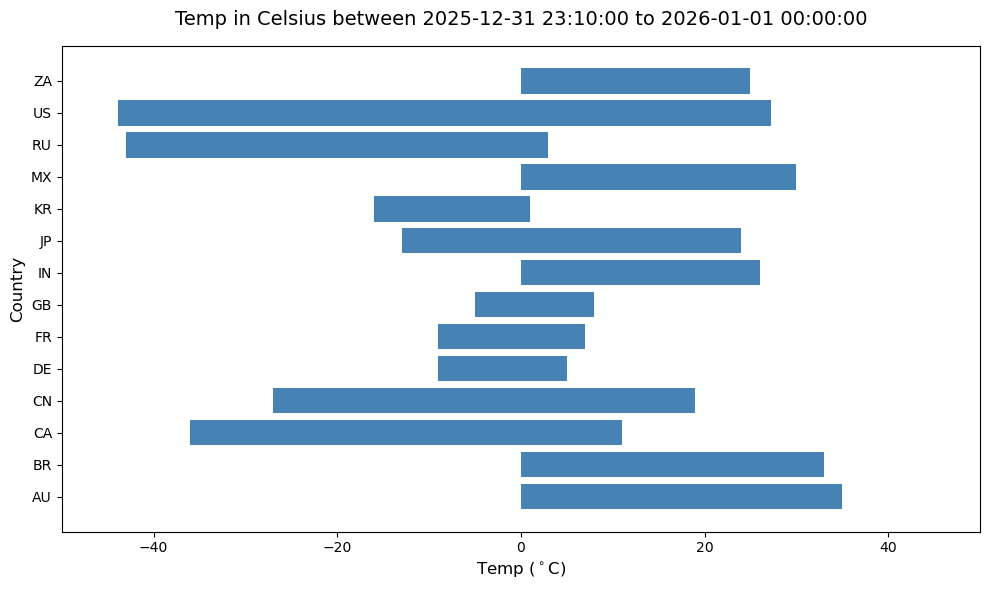

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(df['country'], df['tmpc'], color='#4682b4')

ax.set_title('Temp in Celsius between 2025-12-31 23:10:00 to 2026-01-01 00:00:00', fontsize=14, pad=15)
ax.set_xlabel('Temp ($^\circ$C)', fontsize=12)
ax.set_xlim(-50, 50)
ax.set_ylabel('Country', fontsize=12)

# for bar in bars:
#     width = bar.get_width()
#     ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
#             f'{width}%', 
#             va='center', ha='left', fontsize=11, fontweight='bold')

#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('Temp.pdf', bbox_inches='tight')

In [24]:
from numpy.random import default_rng
from pandas import Series, MultiIndex

rng = default_rng(0)

country = [ 'ZA', 'MX', 'CA', 'RU', 'KR', 'DE', 'BR', 'CN', 'GB', 'US', 'AU', 'IN', 'JP', 'FR']
years = (df['valid'])

index = MultiIndex.from_product([country, years], names=['country', 'valid'])
s = Series(rng.integers(20, 100, size=len(index)), index=index, name='count')

s

country  valid                    
ZA       2025-12-31 23:00:00+00:00    88
         2026-01-01 00:00:00+00:00    70
         2025-12-31 23:00:00+00:00    60
         2025-12-31 23:30:00+00:00    41
         2025-12-31 23:00:00+00:00    44
                                      ..
FR       2026-01-01 00:00:00+00:00    25
         2026-01-01 00:00:00+00:00    84
         2026-01-01 00:00:00+00:00    67
         2026-01-01 00:00:00+00:00    59
         2025-12-31 23:47:00+00:00    57
Name: count, Length: 109018, dtype: int64

In [25]:
df.valid

0      2025-12-31 23:00:00+00:00
1      2026-01-01 00:00:00+00:00
2      2025-12-31 23:00:00+00:00
3      2025-12-31 23:30:00+00:00
4      2025-12-31 23:00:00+00:00
                  ...           
7782   2026-01-01 00:00:00+00:00
7783   2026-01-01 00:00:00+00:00
7784   2026-01-01 00:00:00+00:00
7785   2026-01-01 00:00:00+00:00
7786   2025-12-31 23:47:00+00:00
Name: valid, Length: 7787, dtype: datetime64[us, UTC]

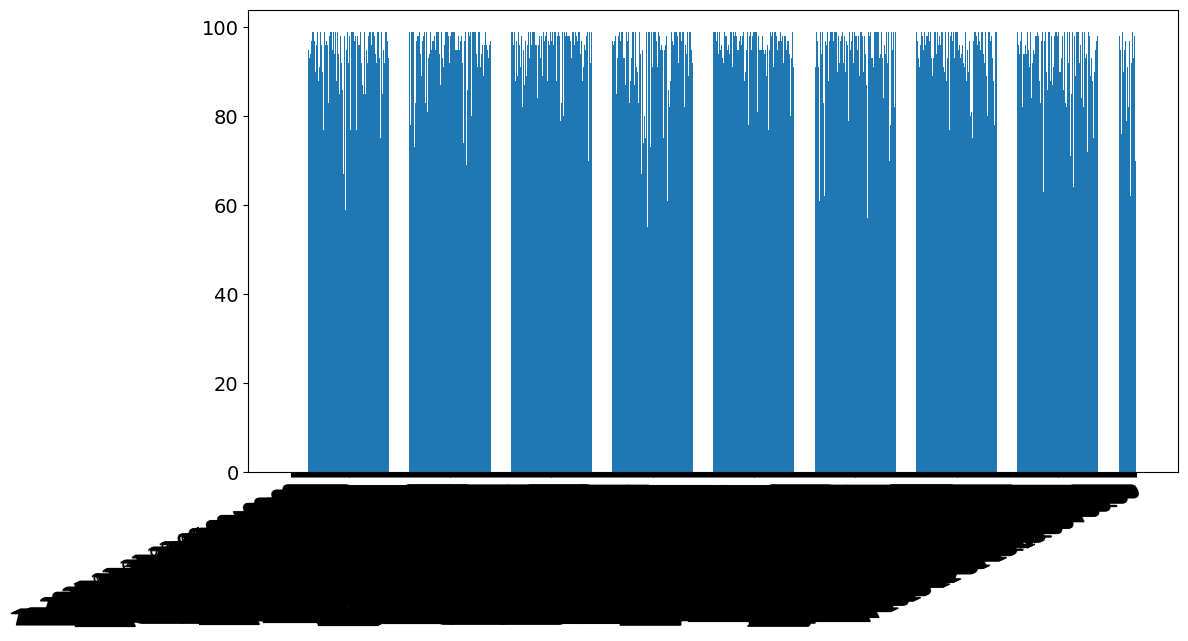

In [26]:
from matplotlib.pyplot import subplots, setp, rc

rc('font', size=14)

fig, ax = subplots(figsize=(12, 6))

xs = s.index.to_flat_index().map(lambda t: ' '.join(str(t_).title() for t_ in t))
ax.bar(xs, s)

setp(ax.get_xticklabels(), rotation=25, ha='right', rotation_mode='anchor');


To calculate and plot average values for many different items (i.e., per country).

In [ ]:
country = [ 'ZA', 'MX', 'CA', 'RU', 'KR', 'DE', 'BR', 'CN', 'GB', 'US', 'AU', 'IN', 'JP', 'FR']
years = (df['valid'])

# 2. Calculate the average for each country
country_averages = [df.mean(country_years) for country_years in years]

# 3. Create the Matplotlib figure
plt.figure(figsize=(8, 5))
plt.bar(country, country_averages, color=['green','grey','indigo','ivory','khaki','lavender','lightblue','lightgreen','lime','magenta','maroon','navy','orange','cyan',])

# 4. Add labels and title
plt.title('Average Values for temp in each country', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Average Value', fontsize=12)

# 5. Show the plot
plt.show()

In [ ]:
from seaborn import barplot

fig, ax = plt.subplots(figsize=(12, 6))

barplot(
    data=s.reset_index(),
    x='country', y='country', hue='valid',
    hue_order=years, palette='Blues',
    ax=ax
)
#bars = ax.barh(df['country'], df['tmpc'], color='#4682b4')
ax.legend(ncol=3, title='Year', loc='lower right', bbox_to_anchor=(1, 1))

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.yaxis.grid(color=ax.get_facecolor())
ax.set_xticklabels([t.get_text().title() for t in ax.get_xticklabels()]);
ax.set_xlabel('');
plt.tight_layout()
#plt.savefig('Temp2.pdf', bbox_inches='tight')
# 5. Show the plot
plt.show()

In [ ]:
from seaborn import barplot

fig, ax = subplots(figsize=(12, 6))

barplot(
    data=s.reset_index(),
    x='country', y='count', hue='valid',
    hue_order=years, palette='Blues',
    ax=ax
)

ax.legend(ncol=3, title='Year', loc='lower right', bbox_to_anchor=(1, 1))

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.yaxis.grid(color=ax.get_facecolor())
ax.set_xticklabels([t.get_text().title() for t in ax.get_xticklabels()]);
ax.set_xlabel('');
